# Value Flipping

`value_flipping` is $x \mapsto -x$. It has **no tunable parameters**. The
operation reverses the apparent direction of trends and oscillations while
leaving temporal dependence (up to a global sign) intact. Applying it twice
recovers the original series exactly.

Use it as a cheap invariance: a model that overfits a persistent upward drift
should still work on the negated copy.


In [1]:
%matplotlib inline
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(os.path.join("..", "..")))

from s2generator.utils import (
    load_univariate,
    generate_arma_samples,
    generate_nonstationary_sine,
    generate_chirp_signal,
)

L = 512
rng = np.random.RandomState(0)
np.random.seed(0)

synth = np.asarray(generate_arma_samples(L), dtype=float)
real = load_univariate("ETTh1")[:L].astype(float)


def overlay_pair(originals, variants, titles, ylabel="value"):
    # Plot original vs augmented traces for synth (left) and real (right).
    n = len(titles)
    fig, axes = plt.subplots(
        n, 2, figsize=(11.5, 2.55 * n), sharex=False, squeeze=False
    )
    col_titles = ["synthetic (ARMA)", "real (ETTh1 OT)"]
    for col, (orig, var_list) in enumerate(zip(originals, variants)):
        for row, (label, series) in enumerate(var_list):
            ax = axes[row, col]
            ax.plot(orig, color="0.55", lw=1.15, label="original")
            ax.plot(series, color="C0", lw=1.15, alpha=0.9, label=label)
            if row == 0:
                ax.set_title(col_titles[col], fontweight="bold")
            if col == 0:
                ax.set_ylabel(ylabel)
            ax.legend(fontsize=8, loc="upper right", frameon=False)
            ax.grid(True, alpha=0.3)
            axes[row, 0].set_ylabel(titles[row], fontsize=10)
    axes[-1, 0].set_xlabel("t")
    axes[-1, 1].set_xlabel("t")
    fig.tight_layout()
    return fig


def sweep_grid(series_list, names, makers, param_title):
    # makers: list of (label, fn) applied to each series.
    n_s, n_p = len(series_list), len(makers)
    fig, axes = plt.subplots(n_s, n_p, figsize=(3.6 * n_p, 2.5 * n_s), squeeze=False)
    for i, (series, name) in enumerate(zip(series_list, names)):
        for j, (label, fn) in enumerate(makers):
            ax = axes[i, j]
            ax.plot(series, color="0.55", lw=1.0, label="original")
            ax.plot(fn(series), color="C3", lw=1.05, alpha=0.9, label=label)
            if i == 0:
                ax.set_title(label, fontsize=10)
            if j == 0:
                ax.set_ylabel(name)
            ax.grid(True, alpha=0.3)
            if i == 0 and j == n_p - 1:
                ax.legend(fontsize=7, loc="upper right", frameon=False)
    fig.suptitle(param_title, y=1.02, fontweight="bold")
    fig.tight_layout()
    return fig


from s2generator.augmentation import value_flipping, add_linear_trend

trended = add_linear_trend(
    synth, trend_strength=1.2, direction="upward", normalize=False
)

## Effect on synthetic (trended ARMA) and real series


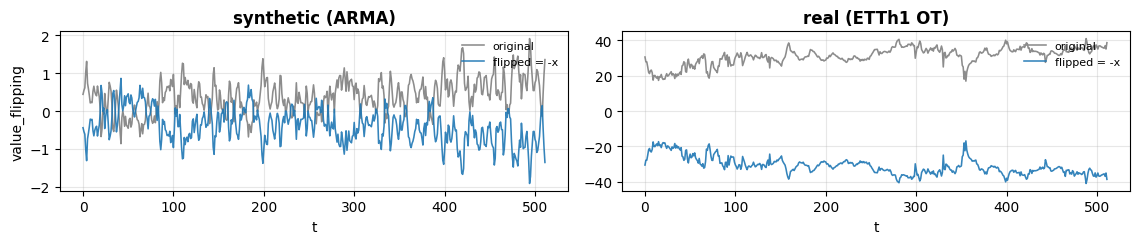

double flip recovers synth? True
double flip recovers real?  True


In [2]:
flip_s = value_flipping(trended)
flip_r = value_flipping(real)
overlay_pair(
    [trended, real],
    [[("flipped = -x", flip_s)], [("flipped = -x", flip_r)]],
    titles=["value_flipping"],
)
plt.show()
print("double flip recovers synth?", np.allclose(value_flipping(flip_s), trended))
print("double flip recovers real? ", np.allclose(value_flipping(flip_r), real))

## What is invariant?

The mean flips sign, the std is unchanged, and the autocorrelation of the series
equals that of `-x`. There is no parameter to sweep; the figure below just
repeats the map on an oscillatory chirp vs ETTh1.


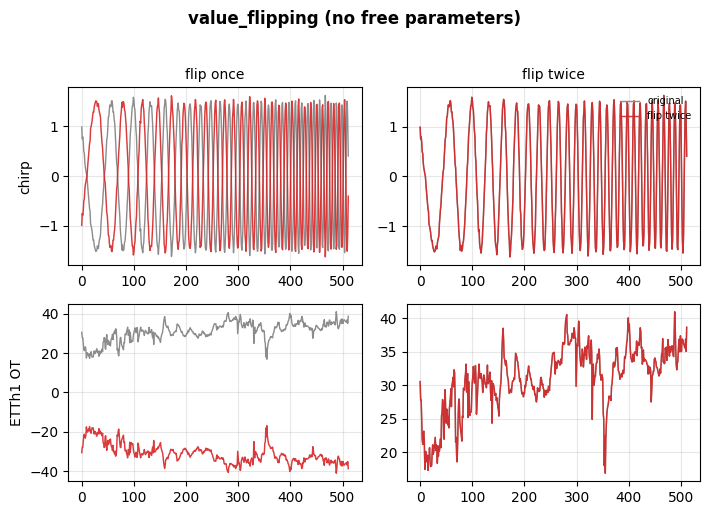

chirp mean -0.026 -> 0.026  std 1.052 -> 1.052  lag-1 acf 0.926 -> 0.926
ETTh1 mean 30.974 -> -30.974  std 4.813 -> 4.813  lag-1 acf 0.934 -> 0.934


In [3]:
chirp = np.asarray(generate_chirp_signal(L), dtype=float)
makers = [
    ("flip once", value_flipping),
    ("flip twice", lambda x: value_flipping(value_flipping(x))),
]
sweep_grid(
    [chirp, real], ["chirp", "ETTh1 OT"], makers, "value_flipping (no free parameters)"
)
plt.show()

for name, x in [("chirp", chirp), ("ETTh1", real)]:
    fx = value_flipping(x)
    acf = lambda z: np.corrcoef(z[:-1], z[1:])[0, 1]
    print(
        name,
        "mean",
        x.mean().round(3),
        "->",
        fx.mean().round(3),
        " std",
        x.std().round(3),
        "->",
        fx.std().round(3),
        " lag-1 acf",
        round(acf(x), 3),
        "->",
        round(acf(fx), 3),
    )